# RetailPulse - Day 6

## LSTM Demand Forecasting using PyTorch

Objective:
Build a Deep Learning LSTM model to forecast future retail demand using historical sales data.

In [5]:
!pip install torch torchvision torchaudio

  Using cached torch-2.12.0-cp313-cp313-win_amd64.whl.metadata (31 kB)
  Using cached torchvision-0.27.0-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached torchaudio-2.11.0-cp313-cp313-win_amd64.whl.metadata (6.9 kB)
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -

In [6]:
import torch

print(torch.__version__)

2.12.0+cpu


In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn

In [8]:
df = pd.read_csv("../data/daily_sales.csv")

df.head()

,Date,Sales
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


In [9]:
print(df.shape)

df.info()

(305, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    305 non-null    object 
 1   Sales   305 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.9+ KB


In [10]:
sales = df["Sales"].values

sales = sales.reshape(-1,1)

print(sales.shape)

(305, 1)


In [11]:
scaler = MinMaxScaler()

sales_scaled = scaler.fit_transform(
    sales
)

In [12]:
def create_sequences(
    data,
    seq_length
):

    X = []
    y = []

    for i in range(
        len(data)-seq_length
    ):

        X.append(
            data[i:i+seq_length]
        )

        y.append(
            data[i+seq_length]
        )

    return (
        np.array(X),
        np.array(y)
    )

In [13]:
SEQ_LENGTH = 30

X,y = create_sequences(
    sales_scaled,
    SEQ_LENGTH
)

print(X.shape)
print(y.shape)

(275, 30, 1)
(275, 1)


In [14]:
split = int(
    len(X)*0.8
)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(220, 30, 1)
(55, 30, 1)


In [15]:
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
)

y_test = torch.tensor(
    y_test,
    dtype=torch.float32
)

In [16]:
class LSTMModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=50,
        num_layers=1
    ):

        super().__init__()

        self.hidden_size = hidden_size

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(
        self,
        x
    ):

        out,_ = self.lstm(x)

        out = self.fc(
            out[:,-1,:]
        )

        return out

In [17]:
model = LSTMModel()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [18]:
epochs = 20

loss_history = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    outputs = model(
        X_train
    )

    loss = criterion(
        outputs,
        y_train
    )

    loss.backward()

    optimizer.step()

    loss_history.append(
        loss.item()
    )

    print(
        f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}"
    )

Epoch 1/20, Loss: 0.023093
Epoch 2/20, Loss: 0.020112
Epoch 3/20, Loss: 0.017374
Epoch 4/20, Loss: 0.014889
Epoch 5/20, Loss: 0.012672
Epoch 6/20, Loss: 0.010738
Epoch 7/20, Loss: 0.009109
Epoch 8/20, Loss: 0.007814
Epoch 9/20, Loss: 0.006879
Epoch 10/20, Loss: 0.006331
Epoch 11/20, Loss: 0.006174
Epoch 12/20, Loss: 0.006372
Epoch 13/20, Loss: 0.006807
Epoch 14/20, Loss: 0.007283
Epoch 15/20, Loss: 0.007622
Epoch 16/20, Loss: 0.007740
Epoch 17/20, Loss: 0.007650
Epoch 18/20, Loss: 0.007416
Epoch 19/20, Loss: 0.007116
Epoch 20/20, Loss: 0.006814


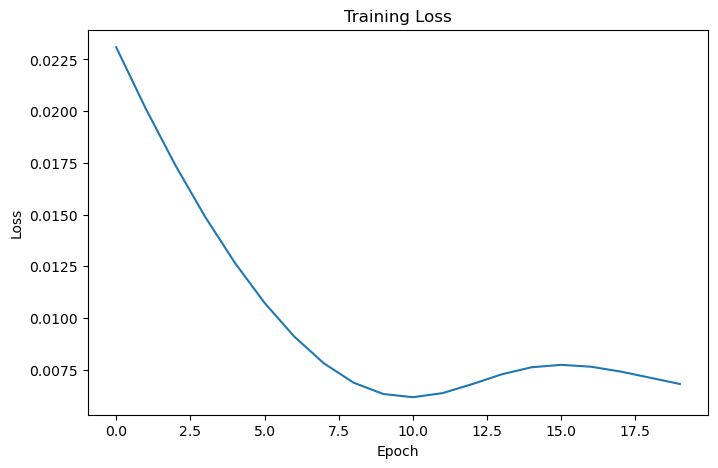

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    loss_history
)

plt.title(
    "Training Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.show()

In [20]:
model.eval()

with torch.no_grad():

    predictions = model(
        X_test
    )

In [21]:
predictions = scaler.inverse_transform(
    predictions.numpy()
)

actual = scaler.inverse_transform(
    y_test.numpy()
)

In [22]:
results = pd.DataFrame({

    "Actual":
    actual.flatten(),

    "Predicted":
    predictions.flatten()

})

results.head()

,Actual,Predicted
0,49089.472656,27838.027344
1,12215.509766,27867.044922
2,42962.796875,28332.759766
3,46401.136719,28388.158203
4,27655.199219,28329.787109


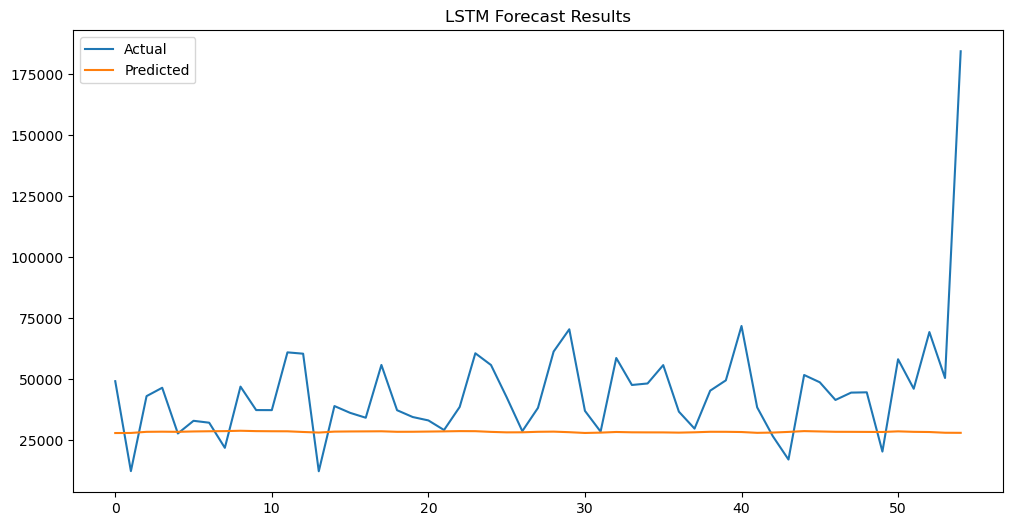

In [23]:
plt.figure(
    figsize=(12,6)
)

plt.plot(
    actual,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.legend()

plt.title(
    "LSTM Forecast Results"
)

plt.show()

In [24]:
rmse = np.sqrt(

    mean_squared_error(
        actual,
        predictions
    )

)

print(
    "RMSE:",
    rmse
)

RMSE: 28678.369828147486


In [26]:
import os

os.makedirs("../models", exist_ok=True)

print("Models folder created")

Models folder created


In [27]:
torch.save(

    model.state_dict(),

    "../models/lstm_model.pth"

)

print(
    "Model Saved"
)

Model Saved


In [28]:
results.to_csv(

    "../data/lstm_predictions.csv",

    index=False

)

print(
    "Predictions Saved"
)

Predictions Saved


# Day 6 Findings

1. Implemented LSTM using PyTorch.

2. Daily sales data was normalized.

3. Time-series sequences were created.

4. LSTM model was trained for 20 epochs.

5. Demand forecasts were generated.

6. Model performance was evaluated using RMSE.

7. Predictions and model were saved.